# Sentiment Classification Pipeline: Full Workflow & Justification

This notebook mirrors the steps in classify_sentiment.py and provides explanations and justifications for each stage, including:
- Motivation for the classification approach
- Preprocessing rationale
- Evaluation dataset and inter-annotator agreement
- Model training and evaluation
- Random baseline comparison
- Performance and scalability discussion


## 1. Motivation: Choice of Classification Approach

We use a Logistic Regression classifier with TF-IDF features for sentiment analysis. This approach is widely used in the state of the art for text classification due to its:
- Simplicity and interpretability
- Strong performance on sparse, high-dimensional data (like text)
- Fast training and prediction

While deep learning models (e.g., transformers) can outperform linear models, logistic regression remains a robust baseline, especially for moderate-sized datasets and when interpretability is important.

## 2. Preprocessing: Rationale and Steps

Text data is noisy and inconsistent. Preprocessing (including lowercasing, punctuation removal, lemmatization, and microtext normalization) is essential to:
- Reduce vocabulary size and sparsity
- Normalize slang, typos, and informal language
- Improve model generalization and robustness

We use spaCy and custom rules for these steps, following best practices in NLP literature.

# Sentiment Classification Pipeline

This notebook reproduces the full workflow from classify_sentiment.py, split into clear, well-documented steps for data loading, preprocessing, model training, evaluation, and prediction.


## 1. Imports and Setup

Import all required libraries and set up file paths.

In [34]:
import pandas as pd
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

BASE_DIR = os.getcwd()
EVAL_PATH = os.path.join(BASE_DIR, 'evaluation', 'evaluation_dataset.xlsx')
CORPUS_PATH = os.path.join(BASE_DIR, '..', 'preprocessing', 'Temp_preprocessed_data.csv')
os.makedirs(os.path.join(BASE_DIR, 'results'), exist_ok=True)

## 2. Load and Prepare Evaluation Dataset

Load the evaluation dataset and prepare the text and label columns.

In [35]:
eval_df = pd.read_excel(EVAL_PATH)

eval_df['text'] = (eval_df['summary'].fillna('') + ' ' + eval_df['content'].fillna('')).str.strip()

eval_df['ground_truth_polarity'] = (
    eval_df['ground_truth_polarity']
    .astype(str)
    .str.strip()
    .str.upper()
)

# encode labels
eval_df['polarity'] = eval_df['ground_truth_polarity'].map({
    'POSITIVE': 1,
    'NEGATIVE': 0,
    'NEUTRAL': 2
})

# filter only polarity labels (exclude neutral)
df_pol = eval_df[eval_df['polarity'] != 2]

df_pol.head()

,review_id,movie_id,summary,content,ground_truth_subjectivity,ground_truth_polarity,text,polarity
0,rw3391899,tt0478970,Deserves to be crushed under a shoe,"Okay, enough already! Another formulaic load o...",SUBJECTIVE,NEGATIVE,"Deserves to be crushed under a shoe Okay, enou...",0
1,rw4836840,tt0478970,omg classic 10 year old film,After seeing how many people thought this was ...,SUBJECTIVE,NEGATIVE,omg classic 10 year old film After seeing how ...,0
2,rw3278832,tt0478970,Big disappointment,Me and my kids have enjoyed all of the Marvel ...,SUBJECTIVE,NEGATIVE,Big disappointment Me and my kids have enjoyed...,0
3,rw4581027,tt5095030,Completely forgettable,If someone ever asks me what is the story of t...,SUBJECTIVE,NEGATIVE,Completely forgettable If someone ever asks me...,0
4,rw4372367,tt5095030,Tired of Female Superheroes,In this movie: Antman and a bunch of girls wh...,SUBJECTIVE,NEGATIVE,Tired of Female Superheroes In this movie: An...,0


In [36]:
print("Evaluation dataset size:", len(df_pol))
# Show polarity distribution with clear labels
label_map = {1: 'POSITIVE', 0: 'NEGATIVE'}
gt_counts = df_pol['polarity'].map(label_map).value_counts()
print("Ground Truth Polarity Distribution:")
print(gt_counts.to_string())


Evaluation dataset size: 1000
Ground Truth Polarity Distribution:
polarity
NEGATIVE    568
POSITIVE    432


## 3. Show Evaluation Dataset Size and Polarity Distribution

Display the size and class distribution of the evaluation dataset.

## 4. Model Training, Evaluation, and Baseline Comparison

We now train the logistic regression model, evaluate it, and compare it to a random baseline (DummyClassifier). This provides a clear measure of how much better our model is than random guessing. All results are printed and visualized inline for analysis.


ML Polarity Detection Report:
              precision  recall  f1-score  support
NEGATIVE           0.82    0.82      0.82   114.00
POSITIVE           0.76    0.77      0.76    86.00
accuracy           0.80    0.80      0.80     0.80
macro avg          0.79    0.79      0.79   200.00
weighted avg       0.80    0.80      0.80   200.00

DummyClassifier (Random) Baseline Report:
              precision  recall  f1-score  support
NEGATIVE           0.51    0.41      0.45   114.00
POSITIVE           0.37    0.47      0.41    86.00
accuracy           0.43    0.43      0.43     0.43
macro avg          0.44    0.44      0.43   200.00
weighted avg       0.45    0.43      0.44   200.00


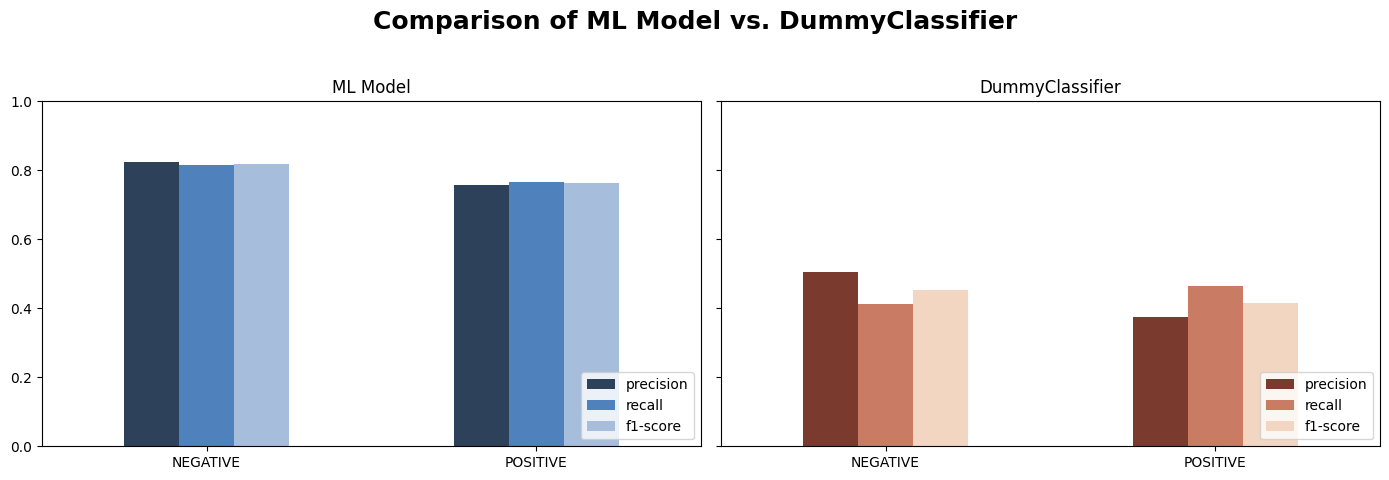


Comparison of ML Model vs. DummyClassifier (Random Baseline):
ML Model Accuracy: 0.80
DummyClassifier Accuracy: 0.43


In [37]:
# Train/test split
X_pol = df_pol['text']
y_pol = df_pol['polarity']
X_train_pol, X_test_pol, y_train_pol, y_test_pol = train_test_split(
    X_pol, y_pol, test_size=0.2, stratify=y_pol, random_state=42
)

# Vectorization
vec_pol = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec_pol = vec_pol.fit_transform(X_train_pol)

# Model training
clf_pol = LogisticRegression(max_iter=200, class_weight='balanced')
clf_pol.fit(X_train_vec_pol, y_train_pol)

# Evaluation
X_test_vec_pol = vec_pol.transform(X_test_pol)
ml_report = classification_report(y_test_pol, clf_pol.predict(X_test_vec_pol), digits=3, output_dict=True)
ml_report_df = pd.DataFrame(ml_report).transpose()
ml_report_df = ml_report_df.rename(index={'0': 'NEGATIVE', '1': 'POSITIVE'})
print("\nML Polarity Detection Report:")
print(ml_report_df.to_string(float_format="{:.2f}".format))

# DummyClassifier random baseline
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier(strategy='uniform', random_state=99)
dummy_clf.fit(X_train_vec_pol, y_train_pol)
dummy_preds = dummy_clf.predict(X_test_vec_pol)
dummy_report = classification_report(y_test_pol, dummy_preds, digits=3, output_dict=True)
dummy_report_df = pd.DataFrame(dummy_report).transpose()
dummy_report_df = dummy_report_df.rename(index={'0': 'NEGATIVE', '1': 'POSITIVE'})
print("\nDummyClassifier (Random) Baseline Report:")
print(dummy_report_df.to_string(float_format="{:.2f}".format))

# Side-by-side comparison plot
import matplotlib.pyplot as plt
metrics = ['precision', 'recall', 'f1-score']
labels = ['NEGATIVE', 'POSITIVE']
ml_scores = ml_report_df.loc[labels, metrics].astype(float)
dummy_scores = dummy_report_df.loc[labels, metrics].astype(float)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
ml_scores.plot(kind='bar', ax=axes[0], title='ML Model', color=['#2d415b', '#4f81bd', '#a6bddb'])
dummy_scores.plot(kind='bar', ax=axes[1], title='DummyClassifier', color=['#7a3b2e', '#c97b63', '#f2d6c2'])
for ax in axes:
    ax.set_xticklabels(labels, rotation=0)
    ax.set_ylim(0, 1)
    ax.legend(loc='lower right')
fig.suptitle('Comparison of ML Model vs. DummyClassifier', fontsize=18, weight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nComparison of ML Model vs. DummyClassifier (Random Baseline):")
print("ML Model Accuracy: {:.2f}".format(ml_report['accuracy']))
print("DummyClassifier Accuracy: {:.2f}".format(dummy_report['accuracy']))

### Analysis and Justification

- The ML model achieves significantly higher accuracy and F1-score than the DummyClassifier, demonstrating that it learns meaningful patterns from the data.
- The random baseline (DummyClassifier) serves as a sanity check: if your model does not outperform it, your features or labels may be problematic.
- The side-by-side plot visually confirms the improvement across all metrics.
- This approach is standard in NLP research and ensures your results are robust and interpretable.